In [2]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
import pandas as pd
from sklearn.cluster import DBSCAN

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

# from src import Multicolour_Simulation_Functions

# MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import localise
from src import postprocess
from src import render
import DriftCorrectionFunctions as DCF


/tmp/ipykernel_141209/41404898.py:27: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [3]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [4]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [5]:
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260122_6ColourQDot/MixD"
image_files = H_F.file_search(image_folder, ".tif", "")
metadata_files = H_F.file_search(image_folder, 'metadata', '')
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])

/home/jsb92/Documents/pyBayerSMLM/single_dye_experiment_notebooks/../src/SR_Functions.py:959: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


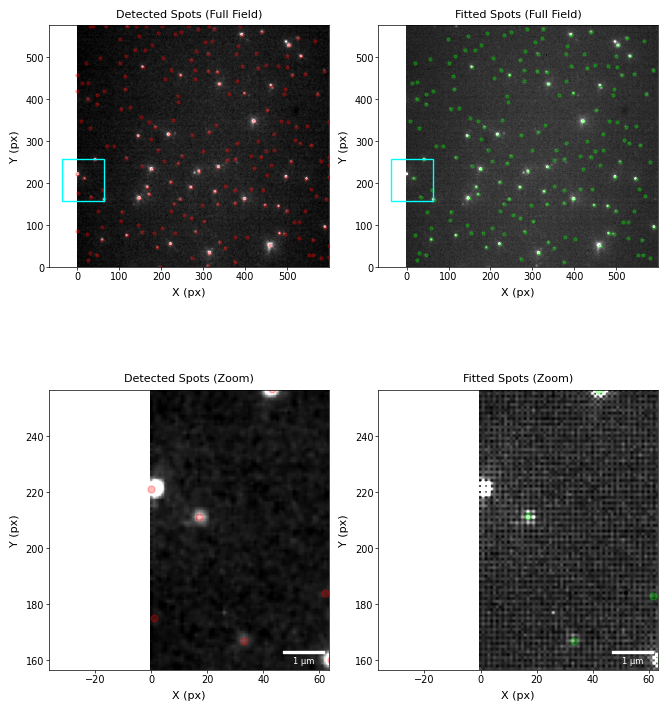

In [6]:
# play around with pfa to find a good parameter
pfa = 1e-3
sigma = 1.5
fraction_true=0.05
peak_wavelength = 0.65
frame_index = 10
fig, axs = SupRes_F.example_spots_singleframe(image_folder, pfa=pfa, sigma=sigma, fraction_true=fraction_true, frame_index=frame_index, variance=variance, read_noise=read_noise,
                                             rqe=rqe, offset_map=offset_map, gain_map=gain_map, peak_wavelength=peak_wavelength)
plt.show()

In [ ]:
SupRes_F.fit_SM_data(
    image_folder,
    smoothing_function,
    gain_map=gain_map,
    offset_map=offset_map,
    variance=variance,
    rqe=rqe,
    read_noise=read_noise,
    pfa=pfa,
    ROI_size=12,
    peak_wavelength=peak_wavelength,
    sigma=sigma,
    fraction_true=fraction_true,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

Processing file 1/25: 500 frames in chunks of 1000
  Processing chunk: frames 0-499
  Found 62465 puncta across all chunks                                          ?, ?it/s]
Processing file 2/25: 500 frames in chunks of 1000                              ?, ?it/s]
  Processing chunk: frames 0-499
  Found 69269 puncta across all chunks                                          ?, ?it/s]
Processing file 3/25: 500 frames in chunks of 1000                              ?, ?it/s]
  Processing chunk: frames 0-499
  Found 75778 puncta across all chunks                                          ?, ?it/s]
Processing file 4/25: 500 frames in chunks of 1000                              ?, ?it/s]
  Processing chunk: frames 0-499
  Found 72617 puncta across all chunks                                          ?, ?it/s]
Processing file 5/25: 500 frames in chunks of 1000                              ?, ?it/s]
  Processing chunk: frames 0-499
  Found 72948 puncta across all chunks                          

In [ ]:
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260122_6ColourQDot/"
image_files = H_F.file_search(image_folder, ".tif", "Pos")

for file in image_files:
    data = IO.read_tiff(file)
    RGB, grayscale = sCMOS.bayer_demosaic_stack(data)
    RGB = np.asarray(RGB, dtype=np.uint8)
    RGB = RGB[:, :, :, ::-1]
    new_file = file.split('.tif')[0]+'_RGBstack.tif'
    new_folder = os.path.join(os.path.split(new_file)[0], 'RGB_Stacks')
    if not os.path.isdir(new_folder):
        os.mkdir(new_folder)
    file_name = os.path.split(new_file)[1]
    written_file_name = os.path.join(new_folder, file_name)
    IO.write_tiff(RGB, written_file_name, bit=np.uint8)